# Which pages should I review first for a content refresh?
**Ibrahim Irfan Nazar | Refresh / Content Opportunity Scoring | ML-11 and ML-12**

I started with a simple idea: an editor with time for 20 to 50 pages needs a short, useful list. This notebook brings together my early questions, my rule baseline, and the starter-model experiment. I keep the numbers next to the explanation so I can check what I am saying.

Run the cells in order. They rebuild the experiment, save the metrics, draw six figures, and create `work/capstone_report.html`. Only summary information is displayed. My March warehouse exercise is discussed as earlier work; the fresh experiments use both the bundled starter CSV and the Hugging Face warehouse.

## Abstract

Which mature pages should a content team review first when it has only 20 to 50 slots? I studied both the 30,000-page starter CSV and a separate monthly forecast built from the Hugging Face warehouse. The CSV comparison uses held-out clients with an overlapping historical label, while the warehouse keeps feature months before outcome months and reserves separate clients for its final May-to-June check. The CSV model reaches 74% Precision@50 versus 24% for its reference rule, and the warehouse model reaches 80.0% versus 96.0% for its momentum rule, with base rates of 39.1% and 31.1%, respectively. The model wins the CSV comparison while the simple momentum rule wins the warehouse forecast, and neither experiment proves that a refresh will recover traffic.

## Setup
I use the same data, feature definitions, model settings, and client split as the reference pipeline so the old and new results can be compared. I keep the model fitted on training clients for every evaluation below. I do not use the reference prediction export, because it comes from models refitted on all rows.

From the repository root, install the project requirements and notebook tools once:
```text
python -m pip install -r requirements.txt
python -m pip install -r work/requirements-capstone.txt
```
Then run this notebook in Jupyter, or use `python work/scripts/run_capstone.py`.

In [1]:
from pathlib import Path
import sys, json, hashlib, importlib.util, platform
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.metrics import confusion_matrix
from IPython.display import display, Markdown, SVG

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/raw/content_refresh_anonymized.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook inside your cloned Flyrank- repository.')
sys.dont_write_bytecode = True
sys.path.insert(0, str(ROOT / 'scripts'))
from ml_utils import (NUMERIC_COLUMNS, CATEGORICAL_COLUMNS, MODEL_NUMERIC_FEATURES,
                      MODEL_CATEGORICAL_FEATURES, percentile_rank, normalize)
spec = importlib.util.spec_from_file_location('reference_training', ROOT / 'scripts/03_train_model.py')
training = importlib.util.module_from_spec(spec)
spec.loader.exec_module(training)
sys.path.insert(0, str(ROOT / 'work/scripts'))
from capstone_report import save_paper

SEED = 42
OUT = ROOT / 'work/outputs'
FIG = ROOT / 'work/figures'
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)
RAW = ROOT / 'data/raw/content_refresh_anonymized.csv'
sections = []
checks = {}
def section(title, body):
    text = '## ' + title + '\n\n' + body.strip()
    sections.append(text)
    display(Markdown(text))
def table(frame):
    def cell(value):
        if isinstance(value, (float, np.floating)):
            return f'{value:.3f}'
        return str(value).replace('|', '/').replace('\n', ' ')
    rows = ['| ' + ' | '.join(map(str, frame.columns)) + ' |',
            '| ' + ' | '.join(['---'] * len(frame.columns)) + ' |']
    rows.extend('| ' + ' | '.join(cell(v) for v in row) + ' |'
                for row in frame.itertuples(index=False, name=None))
    return '\n'.join(rows)
def figure(name, caption):
    plt.savefig(FIG / (name + '.svg'), bbox_inches='tight', metadata={'Date': None})
    plt.savefig(FIG / (name + '.png'), dpi=160, bbox_inches='tight')
    plt.close()
    display(SVG(filename=str(FIG / (name + '.svg'))))
    display(Markdown(caption))
    sections.append('![' + caption + '](figures/' + name + '.svg)\n\n*' + caption + '*')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'svg.fonttype': 'none'})
BLUE, TEAL, GOLD, GREY = '#1d4ed8', '#087f8c', '#b45309', '#64748b'
print('Ready. Seed: 42. Outputs contain summaries and charts only.')

Ready. Seed: 42. Outputs contain summaries and charts only.


## 1. My question and the data behind it
My first notebook counted how many pages were declining. I repeat that check here instead of copying the number from a saved output. I also check the grain, the filter, and missing measurements before fitting anything.

In [2]:
raw = pd.read_csv(RAW)
assert raw.shape == (30000, 44)
assert raw['content_id'].is_unique and raw['client_id'].notna().all()
assert raw['trend_direction'].notna().all()
assert set(raw['trend_direction'].unique()) <= {'down', 'up', 'stable', 'new', 'flat'}
frame = raw.copy()
# Reproduce the reference preparation. Its zero-fill policy is discussed below.
for col in NUMERIC_COLUMNS:
    frame[col] = pd.to_numeric(frame[col], errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)
for col in CATEGORICAL_COLUMNS:
    frame[col] = frame[col].fillna('unknown').astype(str).replace({'': 'unknown', 'nan': 'unknown'})
frame = frame[(frame['impressions_90d'] > 0) & (frame['content_age_days'] >= 90)]
frame = frame.drop_duplicates('content_id').reset_index(drop=True)
frame['is_declining_label'] = frame['trend_direction'].str.lower().eq('down').astype(int)
for name in ['impressions', 'clicks', 'sessions', 'ai_sessions']:
    frame['log_' + name + '_90d'] = np.log1p(frame[name + '_90d'])
y = frame['is_declining_label']
assert len(frame) == len(raw)
checks['unique_pages_and_complete_groups'] = True
checks['prepared_rows_match_raw_rows'] = True
high_impact = int(((y == 1) & (frame['impressions_90d'] >= 1000)).sum())
missing = pd.DataFrame({
    'Measurement': ['Word count missing', 'Search-volume estimate missing', 'Position unavailable (zero)'],
    'Pages': [int(raw['word_count'].isna().sum()), int(raw['search_volume'].isna().sum()),
              int(raw['avg_position'].eq(0).sum())]})
section('1. Problem framing', f"""
I want to help a content team decide which 20 to 50 mature pages to inspect first each month. One row is one page, and the output is a ranked review list. An editor still checks the page, its purpose, and recent changes before deciding what to edit.

In this starter sample, {int(y.sum()):,} of {len(frame):,} pages ({y.mean():.1%}) have the declining label. Of those, {high_impact:,} have at least 1,000 impressions over 90 days. That is too many pages to inspect one by one. A poor pick uses time on a page that may not need work; a missed pick can leave a useful page unattended.

This is a ranking exercise. It measures how often the first picks match observed decline. It does not measure traffic recovered, money saved, or the benefit of a rewrite.
""")
section('2. Data and safety', f"""
I use the bundled `data/raw/content_refresh_anonymized.csv`: {len(raw):,} rows, {raw.shape[1]} columns, and {raw['client_id'].nunique()} pseudonymized clients. Search and engagement measurements cover a trailing 90-day window. The supplied CSV does not record exact calendar start and end dates, so I do not assign the warehouse release dates to it.

The reference filter keeps pages with at least one impression and age of at least 90 days, then removes duplicate page IDs. All {len(frame):,} rows pass. Unlike my week-2 candidate filter, this comparison retains pages with unavailable position to match the supplied capstone benchmark.

{table(missing)}

Missing word count is not proof of short content. Position zero means no position measurement. Rates such as CTR are already percentages: 0.5 means 0.5%. Scroll rate and AI traffic share can exceed 100 because of their measurement definitions.

Page and client IDs are used only for joining, checking uniqueness, and splitting. The report contains aggregates and broad review bands, with no client names, page addresses, raw queries, or pseudonymous ID values. Numeric keyword context is allowed; keyword text is absent. The file fingerprint and exact package versions are in the metrics receipt.
""")

## 1. Problem framing

I want to help a content team decide which 20 to 50 mature pages to inspect first each month. One row is one page, and the output is a ranked review list. An editor still checks the page, its purpose, and recent changes before deciding what to edit.

In this starter sample, 16,262 of 30,000 pages (54.2%) have the declining label. Of those, 8,031 have at least 1,000 impressions over 90 days. That is too many pages to inspect one by one. A poor pick uses time on a page that may not need work; a missed pick can leave a useful page unattended.

This is a ranking exercise. It measures how often the first picks match observed decline. It does not measure traffic recovered, money saved, or the benefit of a rewrite.

## 2. Data and safety

I use the bundled `data/raw/content_refresh_anonymized.csv`: 30,000 rows, 44 columns, and 32 pseudonymized clients. Search and engagement measurements cover a trailing 90-day window. The supplied CSV does not record exact calendar start and end dates, so I do not assign the warehouse release dates to it.

The reference filter keeps pages with at least one impression and age of at least 90 days, then removes duplicate page IDs. All 30,000 rows pass. Unlike my week-2 candidate filter, this comparison retains pages with unavailable position to match the supplied capstone benchmark.

| Measurement | Pages |
| --- | --- |
| Word count missing | 7699 |
| Search-volume estimate missing | 2468 |
| Position unavailable (zero) | 1205 |

Missing word count is not proof of short content. Position zero means no position measurement. Rates such as CTR are already percentages: 0.5 means 0.5%. Scroll rate and AI traffic share can exceed 100 because of their measurement definitions.

Page and client IDs are used only for joining, checking uniqueness, and splitting. The report contains aggregates and broad review bands, with no client names, page addresses, raw queries, or pseudonymous ID values. Numeric keyword context is allowed; keyword text is absent. The file fingerprint and exact package versions are in the metrics receipt.

## 2. What I carried forward from weeks 1 to 4
I keep my original question and the stale-and-visible rule. I also correct claims that the earlier evidence cannot support. Saved warehouse outputs are useful history, but they are not a fresh warehouse evaluation.

In [3]:
section('Earlier work: what changed my thinking', """
In week 1, I settled on refresh review because the declining-page count was large. In week 2, I tried a stale-and-visible rule and small decision trees. The useful lesson was to compare actual results, rather than assume the more complex method would win.

In weeks 3 and 4, I explored the March 2026 warehouse partition using daily search facts and content metadata. The saved outputs report 9,841,378 daily rows, 61,863 filtered pages, a 38.3% declining rate, and Precision@20 of 10.0%. These are historical notebook outputs, not numbers recomputed by this capstone. One later output says 10 wrong picks out of 20; 10% precision would imply 18 wrong picks. Those saved cells are inconsistent, so I do not use them as a verified result or mix them with the starter benchmark.

There is also a method issue worth keeping visible. Those March features use the full month, including the second half that defines the label. Removing the named future-impressions column does not remove that overlap. The label compares 15 days with 16 days, and current metadata may not describe what was known halfway through March. Weak score-label correlation cannot certify that a feature is safe. An average position outside the first page also cannot establish that position has fallen.

A future warehouse experiment should use features and eligible pages defined before the outcome, comparable exposure windows, and metadata known at the decision date. June was intended as a later test month in my earlier work; the warehouse extension below now evaluates a separately designed May-to-June forecast after model selection.
""")

## Earlier work: what changed my thinking

In week 1, I settled on refresh review because the declining-page count was large. In week 2, I tried a stale-and-visible rule and small decision trees. The useful lesson was to compare actual results, rather than assume the more complex method would win.

In weeks 3 and 4, I explored the March 2026 warehouse partition using daily search facts and content metadata. The saved outputs report 9,841,378 daily rows, 61,863 filtered pages, a 38.3% declining rate, and Precision@20 of 10.0%. These are historical notebook outputs, not numbers recomputed by this capstone. One later output says 10 wrong picks out of 20; 10% precision would imply 18 wrong picks. Those saved cells are inconsistent, so I do not use them as a verified result or mix them with the starter benchmark.

There is also a method issue worth keeping visible. Those March features use the full month, including the second half that defines the label. Removing the named future-impressions column does not remove that overlap. The label compares 15 days with 16 days, and current metadata may not describe what was known halfway through March. Weak score-label correlation cannot certify that a feature is safe. An average position outside the first page also cannot establish that position has fallen.

A future warehouse experiment should use features and eligible pages defined before the outcome, comparable exposure windows, and metadata known at the decision date. June was intended as a later test month in my earlier work; the warehouse extension below now evaluates a separately designed May-to-June forecast after model selection.

## 3. Build the baselines before looking at the models
The repo score is a weighted rule. My earlier rule is even simpler: if a page is at least 180 days since update and has at least 500 impressions, rank it by impressions. I keep both thresholds fixed.

## 3. Baseline

The reference rule combines four things: visibility (40%), time since update (30%), position opportunity (25%), and a word-count gap (5%). It uses no fitted weights. Both it and the models are scored on exactly the same held-out pages and labels.

Visibility and freshness are percentile ranks across this fixed sample. Position opportunity gives more weight to a measured position closer to the top, multiplied by visibility. The word-count gap is the inverse word-count percentile, also multiplied by visibility. These are simple priorities, not established causes of decline. The full formulas are in the notebook.

My earlier rule is `stale x visible x impressions`. It produces 17 positive scores across the sample and 0 on the held-out clients. With no eligible held-out pages, every score there ties at zero. An arbitrary top 50 would measure file ordering, so I report no meaningful Precision@50 for that rule. Random tie-breaking would average the held-out declining rate (39.1%). This rule needs review before it could serve that group.

For an exact reference comparison, the baseline percentiles and category vocabulary use the full sample, as the original pipeline does. No held-out labels enter fitting, but this is not a fully independent preprocessing test. A stricter deployment experiment would learn those transformations on training data only.

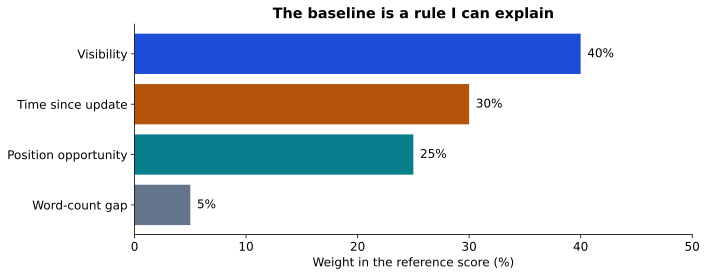

Figure 1. These are fixed policy weights, not learned effects or a measure of traffic recovery.

In [4]:
visibility = percentile_rank(np.log1p(frame['impressions_90d']))
freshness = percentile_rank(frame['days_since_last_update'])
position = ((1 - normalize(frame['avg_position'].clip(1, 50))) * visibility
            * frame['avg_position'].gt(0).astype(int))
depth_gap = (1 - percentile_rank(frame['word_count'])) * visibility
baseline_score = (.40 * visibility + .30 * freshness + .25 * position + .05 * depth_gap).clip(0, 1)
hand_score = (frame['days_since_last_update'].ge(180).astype(int)
              * frame['impressions_90d'].ge(500).astype(int) * frame['impressions_90d'])

X, encoded_features = training.build_feature_matrix(frame)
train_idx, test_idx, split_strategy = training.make_client_aware_split(frame, y)
assert split_strategy == 'client_holdout'
assert set(frame.iloc[train_idx]['client_id']).isdisjoint(set(frame.iloc[test_idx]['client_id']))
assert set(train_idx).isdisjoint(test_idx)
assert len(train_idx) + len(test_idx) == len(frame)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
base_rate = float(y_test.mean())
checks['client_and_row_overlap_zero'] = True
hand_eligible_all = int(hand_score.gt(0).sum())
hand_eligible_test = int(hand_score.iloc[test_idx].gt(0).sum())
section('3. Baseline', f"""
The reference rule combines four things: visibility (40%), time since update (30%), position opportunity (25%), and a word-count gap (5%). It uses no fitted weights. Both it and the models are scored on exactly the same held-out pages and labels.

Visibility and freshness are percentile ranks across this fixed sample. Position opportunity gives more weight to a measured position closer to the top, multiplied by visibility. The word-count gap is the inverse word-count percentile, also multiplied by visibility. These are simple priorities, not established causes of decline. The full formulas are in the notebook.

My earlier rule is `stale x visible x impressions`. It produces {hand_eligible_all} positive scores across the sample and {hand_eligible_test} on the held-out clients. With no eligible held-out pages, every score there ties at zero. An arbitrary top 50 would measure file ordering, so I report no meaningful Precision@50 for that rule. Random tie-breaking would average the held-out declining rate ({base_rate:.1%}). This rule needs review before it could serve that group.

For an exact reference comparison, the baseline percentiles and category vocabulary use the full sample, as the original pipeline does. No held-out labels enter fitting, but this is not a fully independent preprocessing test. A stricter deployment experiment would learn those transformations on training data only.
""")
fig, ax = plt.subplots(figsize=(10, 3.8))
weights = [40, 30, 25, 5]
labels = ['Visibility', 'Time since update', 'Position opportunity', 'Word-count gap']
ax.barh(labels[::-1], weights[::-1], color=[GREY, TEAL, GOLD, BLUE])
ax.set(xlim=(0, 50), xlabel='Weight in the reference score (%)', title='The baseline is a rule I can explain')
for i, value in enumerate(weights[::-1]): ax.text(value + .6, i, f'{value}%', va='center')
figure('baseline_weights', 'Figure 1. These are fixed policy weights, not learned effects or a measure of traffic recovery.')

## 4. Fit the models and keep the evaluation separate
The target is a recent historical label. I exclude its direct ingredients from the feature list. The 90-day features still overlap the label window, so this is a snapshot ranking benchmark, not a forecast.

## 4. Methodology and model

The target is `is_declining_label = (trend_direction == 'down')`. The data dictionary defines down as a fall of more than 20% in last-30-day impressions relative to the preceding 30 days. This is a rule-based summary of observed traffic, not a label saying that an editor should rewrite a page.

I compare logistic regression, a depth-5 decision tree, and a random forest with 200 trees, depth 10, and at least 25 rows per leaf. The decision tree has at least 50 rows per leaf. The models use class balancing; logistic regression standardizes its inputs using training rows. Seed 42 fixes the client shuffle and model randomness.

**Numeric inputs (18):** `search_volume`, `competition`, `cpc`, `word_count`, `char_count`, `log_impressions_90d`, `log_clicks_90d`, `log_sessions_90d`, `log_ai_sessions_90d`, `days_with_impressions`, `days_with_sessions`, `content_age_days`, `days_since_last_update`, `ctr`, `avg_position`, `engagement_rate`, `scroll_rate`, `ai_traffic_pct`.

**Categorical inputs (8):** `competition_level`, `content_type`, `main_intent`, `age_tier`, `freshness_tier`, `word_count_tier`, `impression_tier`, `position_tier`.

These become 52 encoded model columns. The reference preparation fills numeric gaps with zero and missing categories with `unknown`; it logs four traffic totals with `log1p`. I retain this policy to reproduce the benchmark, but zero can mix missing measurements with real zeros. Missingness indicators and training-only imputation are useful next checks, not improvements measured here.

Direct trend fields, the six 30-day comparison inputs, IDs, provider/model metadata, and product scores are excluded from model inputs. That check does not establish temporal independence: the retained 90-day totals overlap the recent label window.

The split holds out 6 of 32 whole clients: 27,675 training pages and 2,325 held-out pages. It is about 20% of clients, not 20% of pages. I compare candidates by Precision@50 on this same split, so it is a development holdout used for selection. It is not an untouched final test, and it does not test future months.

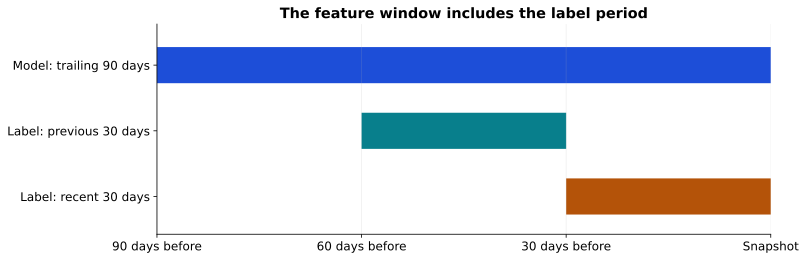

Figure 2. The last two windows define observed decline. Their overlap with model inputs rules out a future-prediction claim.

In [5]:
forbidden = {'content_id', 'client_id', 'trend_direction', 'trend_pct', 'is_declining_label',
             'provider_used', 'model_used', 'health_score', 'priority_score',
             'impressions_last_30d', 'impressions_prev_30d', 'clicks_last_30d',
             'clicks_prev_30d', 'sessions_last_30d', 'sessions_prev_30d'}
declared = set(MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES)
assert not declared.intersection(forbidden)
assert np.isfinite(X.to_numpy()).all()
checks['direct_label_and_identifier_features_excluded'] = True
models = training.build_models()
# A single worker makes resource use predictable on a laptop.
models['random_forest'].set_params(n_jobs=1)
scores = {'baseline_rules': baseline_score.iloc[test_idx].to_numpy()}
metrics = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    scores[name] = model.predict_proba(X_test)[:, 1]
for name, values in scores.items():
    metrics[name] = training.metric_payload(y_test, values)
best_name = max(models, key=lambda name: (metrics[name]['precision_at_50'],
                                         metrics[name]['average_precision'], metrics[name]['roc_auc']))
best = metrics[best_name]
base = metrics['baseline_rules']
train_clients = int(frame.iloc[train_idx]['client_id'].nunique())
test_clients = int(frame.iloc[test_idx]['client_id'].nunique())
section('4. Methodology and model', f"""
The target is `is_declining_label = (trend_direction == 'down')`. The data dictionary defines down as a fall of more than 20% in last-30-day impressions relative to the preceding 30 days. This is a rule-based summary of observed traffic, not a label saying that an editor should rewrite a page.

I compare logistic regression, a depth-5 decision tree, and a random forest with 200 trees, depth 10, and at least 25 rows per leaf. The decision tree has at least 50 rows per leaf. The models use class balancing; logistic regression standardizes its inputs using training rows. Seed 42 fixes the client shuffle and model randomness.

**Numeric inputs ({len(MODEL_NUMERIC_FEATURES)}):** {', '.join('`' + x + '`' for x in MODEL_NUMERIC_FEATURES)}.

**Categorical inputs ({len(MODEL_CATEGORICAL_FEATURES)}):** {', '.join('`' + x + '`' for x in MODEL_CATEGORICAL_FEATURES)}.

These become {len(encoded_features)} encoded model columns. The reference preparation fills numeric gaps with zero and missing categories with `unknown`; it logs four traffic totals with `log1p`. I retain this policy to reproduce the benchmark, but zero can mix missing measurements with real zeros. Missingness indicators and training-only imputation are useful next checks, not improvements measured here.

Direct trend fields, the six 30-day comparison inputs, IDs, provider/model metadata, and product scores are excluded from model inputs. That check does not establish temporal independence: the retained 90-day totals overlap the recent label window.

The split holds out {test_clients} of {train_clients + test_clients} whole clients: {len(train_idx):,} training pages and {len(test_idx):,} held-out pages. It is about 20% of clients, not 20% of pages. I compare candidates by Precision@50 on this same split, so it is a development holdout used for selection. It is not an untouched final test, and it does not test future months.
""")
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.broken_barh([(0, 90)], (2, .55), facecolors=BLUE)
ax.broken_barh([(30, 30)], (1, .55), facecolors=TEAL)
ax.broken_barh([(60, 30)], (0, .55), facecolors=GOLD)
ax.set(yticks=[.275, 1.275, 2.275], yticklabels=['Label: recent 30 days', 'Label: previous 30 days', 'Model: trailing 90 days'],
       xticks=[0, 30, 60, 90], xticklabels=['90 days before', '60 days before', '30 days before', 'Snapshot'],
       xlim=(0,90), ylim=(-.3,2.9), title='The feature window includes the label period')
ax.grid(axis='x', alpha=.2)
figure('time_windows', 'Figure 2. The last two windows define observed decline. Their overlap with model inputs rules out a future-prediction claim.')

## 5. Compare results on the same held-out pages
Precision@50 means the fraction of the first 50 picks carrying the declining label. The base rate for random ranking is the positive-label rate in this same group. Majority-class accuracy answers a different question.

## 5. Results and evaluation

The strongest candidate in this run is **random forest**. It finds **37 declining pages in its first 50 picks**, compared with **12 for the reference rule**. That is 25 additional matches to the historical label, or 50.0 percentage points in Precision@50.

| Method | P@20 | P@50 | P@100 | ROC AUC | Average precision |
| --- | --- | --- | --- | --- | --- |
| baseline rules | 0.150 | 0.240 | 0.360 | 0.627 | 0.468 |
| logistic regression | 0.350 | 0.400 | 0.440 | 0.700 | 0.522 |
| decision tree | 0.550 | 0.620 | 0.600 | 0.742 | 0.575 |
| random forest | 0.650 | 0.740 | 0.720 | 0.750 | 0.618 |

The held-out declining rate is **39.1% (909/2,325)**. Random selection would average 19.5 declining pages in 50 picks; this is an expectation, not another trained model. The majority class is not declining, giving **60.9%** accuracy if every page is assigned that class. The full sample declining rate of 54.2% belongs to a different population.

The supplied metrics file recorded random-forest Precision@50 of 74% and baseline Precision@50 of 24%. I preserve that original receipt and report the fresh values above. The reference ranking helper uses pandas score sorting. A shallow tree has many tied scores, so its top-K result can change with ordering or library versions even when ROC AUC is unchanged. For this run, the tree's top-50 precision can range from 2.0% to 98.0% across valid orders of the boundary ties. The metrics receipt records tie bounds for each method.

This is one grouped development comparison. I have not measured uncertainty across repeated client splits, and I do not claim that the observed margin is statistically significant.

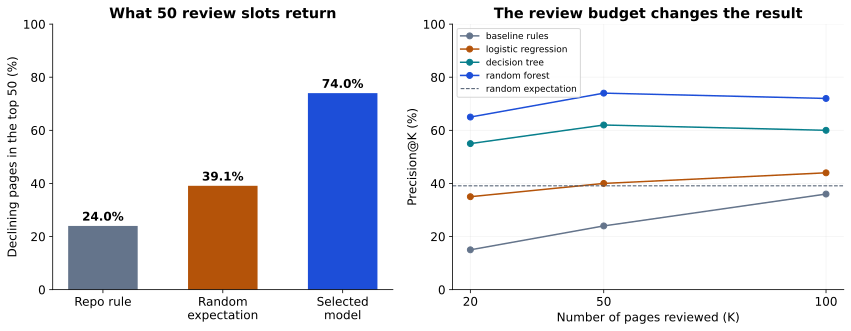

Figure 3. All methods use the same 2,325 held-out pages. The random line is their 39.1% declining rate; connected points summarize K=20, 50, and 100 only.

In [6]:
metric_rows = []
for name in ['baseline_rules', 'logistic_regression', 'decision_tree', 'random_forest']:
    row = metrics[name]
    metric_rows.append({'Method': name.replace('_', ' '), 'P@20': row['precision_at_20'],
                       'P@50': row['precision_at_50'], 'P@100': row['precision_at_100'],
                       'ROC AUC': row['roc_auc'], 'Average precision': row['average_precision']})
metric_frame = pd.DataFrame(metric_rows)
# Bounds show how changing the order of tied scores can affect top-K precision.
def tie_bounds(values, labels, k=50):
    values, labels = np.asarray(values), np.asarray(labels)
    cutoff = np.sort(values)[-k]
    above, tied = values > cutoff, values == cutoff
    slots = k - int(above.sum())
    positive_above = int(labels[above].sum())
    positive_tied = int(labels[tied].sum())
    negative_tied = int(tied.sum()) - positive_tied
    return {'tied_at_cutoff': int(tied.sum()), 'slots_from_ties': slots,
            'minimum_precision': (positive_above + max(0, slots-negative_tied))/k,
            'maximum_precision': (positive_above + min(slots, positive_tied))/k}
ties = {name: tie_bounds(values, y_test) for name, values in scores.items()}
selected_hits = round(best['precision_at_50'] * 50)
baseline_hits = round(base['precision_at_50'] * 50)
section('5. Results and evaluation', f"""
The strongest candidate in this run is **{best_name.replace('_', ' ')}**. It finds **{selected_hits} declining pages in its first 50 picks**, compared with **{baseline_hits} for the reference rule**. That is {selected_hits-baseline_hits} additional matches to the historical label, or {(best['precision_at_50']-base['precision_at_50'])*100:.1f} percentage points in Precision@50.

{table(metric_frame)}

The held-out declining rate is **{base_rate:.1%} ({int(y_test.sum()):,}/{len(y_test):,})**. Random selection would average {50*base_rate:.1f} declining pages in 50 picks; this is an expectation, not another trained model. The majority class is not declining, giving **{max(base_rate,1-base_rate):.1%}** accuracy if every page is assigned that class. The full sample declining rate of {y.mean():.1%} belongs to a different population.

The supplied metrics file recorded random-forest Precision@50 of 74% and baseline Precision@50 of 24%. I preserve that original receipt and report the fresh values above. The reference ranking helper uses pandas score sorting. A shallow tree has many tied scores, so its top-K result can change with ordering or library versions even when ROC AUC is unchanged. For this run, the tree's top-50 precision can range from {ties['decision_tree']['minimum_precision']:.1%} to {ties['decision_tree']['maximum_precision']:.1%} across valid orders of the boundary ties. The metrics receipt records tie bounds for each method.

This is one grouped development comparison. I have not measured uncertainty across repeated client splits, and I do not claim that the observed margin is statistically significant.
""")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={'width_ratios':[1, 1.15]})
a=axes[0]
values=[base['precision_at_50']*100, base_rate*100, best['precision_at_50']*100]
a.bar(['Repo rule', 'Random\nexpectation', 'Selected\nmodel'],values,color=[GREY,GOLD,BLUE],width=.58)
a.set(ylim=(0,100),ylabel='Declining pages in the top 50 (%)',title='What 50 review slots return')
for i,value in enumerate(values):a.text(i,value+2,f'{value:.1f}%',ha='center',fontweight='bold')
a=axes[1]
for name,color in [('baseline_rules',GREY),('logistic_regression',GOLD),('decision_tree',TEAL),('random_forest',BLUE)]:
    a.plot([20,50,100],[metrics[name][f'precision_at_{k}']*100 for k in [20,50,100]],marker='o',color=color,label=name.replace('_',' '))
a.axhline(base_rate*100,color='#475569',linestyle='--',linewidth=1,label='random expectation')
a.set(ylim=(0,100),xticks=[20,50,100],xlabel='Number of pages reviewed (K)',ylabel='Precision@K (%)',title='The review budget changes the result')
a.legend(fontsize=9,loc='upper left');a.grid(alpha=.15)
fig.tight_layout()
figure('precision_comparison', f'Figure 3. All methods use the same {len(y_test):,} held-out pages. The random line is their {base_rate:.1%} declining rate; connected points summarize K=20, 50, and 100 only.')

## 6. Read the mistakes before recommending an action
I compute these errors from predictions made before any full-data refit. Feature importance describes what this fitted model used; it does not tell an editor which change will cause recovery.

## 6. Interpretation and errors

The model's top three importance entries are `days_with_impressions`, `log_impressions_90d`, `avg_position`. These describe the measurements the model used to separate pages in this sample. Their importance is an internal model summary, not evidence that editing one feature changes traffic. Correlated measurements and missing-data patterns can divide or inflate importance.

At the ordinary 0.5 score cutoff, the selected model has 676 true positives, 887 true negatives, 529 false positives, and 233 false negatives. Recall is 74.4%; accuracy is 67.2%, compared with 60.9% majority-class accuracy. This threshold result is separate from choosing the top 50.

| Impressions in 90 days | Pages | Declining rate | False positives | False negatives |
| --- | --- | --- | --- | --- |
| Under 100 | 1430 | 0.300 | 148 | 225 |
| 500-999 | 141 | 0.574 | 60 | 0 |
| 1,000+ | 477 | 0.503 | 204 | 6 |
| 100-499 | 277 | 0.574 | 117 | 2 |

Even at the top of the ranking, 13 of the first 50 picks do not have the declining label. Those are weaker matches to this proxy, not proof that the pages have no editorial value. The false negatives show why the list should not be the only way a team notices problems.

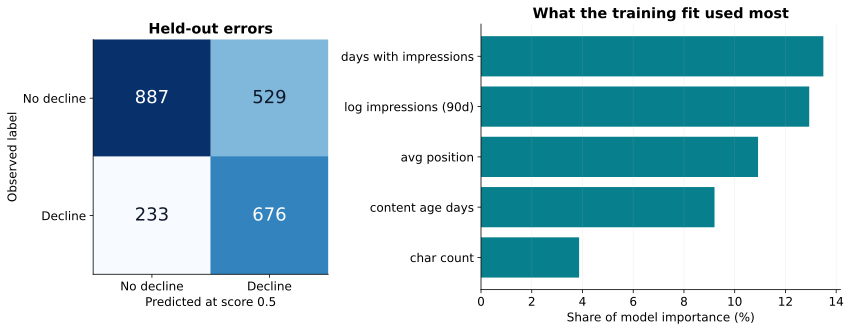

Figure 4. Errors use held-out predictions. Importance comes from the same training fit; neither panel measures the impact of a refresh.

In [7]:
selected_scores = scores[best_name]
cm = confusion_matrix(y_test, selected_scores >= .5, labels=[0,1])
tn, fp, fn, tp = map(int, cm.ravel())
assert cm.sum() == len(test_idx)
assert np.isclose(tp/(tp+fn),best['recall'])
checks['errors_match_training_only_predictions'] = True
importance = training.top_feature_importance(models[best_name], encoded_features, limit=8)
heldout = frame.iloc[test_idx].copy().reset_index(drop=True)
heldout['model_score'] = selected_scores
heldout['prediction'] = (selected_scores >= .5).astype(int)
heldout['volume_band'] = pd.cut(heldout['impressions_90d'],bins=[-1,99,499,999,np.inf],labels=['Under 100','100-499','500-999','1,000+']).astype(str)
error_rows=[]
for band, group in heldout.groupby('volume_band',sort=False):
    error_rows.append({'Impressions in 90 days':band,'Pages':len(group),
                      'Declining rate':group['is_declining_label'].mean(),
                      'False positives':int(((group['prediction']==1)&(group['is_declining_label']==0)).sum()),
                      'False negatives':int(((group['prediction']==0)&(group['is_declining_label']==1)).sum())})
error_frame=pd.DataFrame(error_rows)
top_names=', '.join('`'+v['feature']+'`' for v in importance[:3])
section('6. Interpretation and errors', f"""
The model's top three importance entries are {top_names}. These describe the measurements the model used to separate pages in this sample. Their importance is an internal model summary, not evidence that editing one feature changes traffic. Correlated measurements and missing-data patterns can divide or inflate importance.

At the ordinary 0.5 score cutoff, the selected model has {tp:,} true positives, {tn:,} true negatives, {fp:,} false positives, and {fn:,} false negatives. Recall is {best['recall']:.1%}; accuracy is {best['accuracy']:.1%}, compared with {max(base_rate,1-base_rate):.1%} majority-class accuracy. This threshold result is separate from choosing the top 50.

{table(error_frame)}

Even at the top of the ranking, {50-selected_hits} of the first 50 picks do not have the declining label. Those are weaker matches to this proxy, not proof that the pages have no editorial value. The false negatives show why the list should not be the only way a team notices problems.
""")
fig,axes=plt.subplots(1,2,figsize=(12,4.8),gridspec_kw={'width_ratios':[.85,1.3]})
a=axes[0];a.imshow(cm,cmap='Blues');a.set(xticks=[0,1],xticklabels=['No decline','Decline'],yticks=[0,1],yticklabels=['No decline','Decline'],xlabel='Predicted at score 0.5',ylabel='Observed label',title='Held-out errors')
for i in range(2):
    for j in range(2):a.text(j,i,f'{cm[i,j]:,}',ha='center',va='center',fontsize=18,color='white' if cm[i,j]>cm.max()*.6 else '#0f172a')
a=axes[1];top=pd.DataFrame(importance[:5]).iloc[::-1]
labels=[s.replace('log_','log ').replace('_90d',' (90d)').replace('_',' ') for s in top['feature']]
a.barh(labels,top['importance']*100,color=TEAL);a.set(xlabel='Share of model importance (%)',title='What the training fit used most')
a.grid(axis='x',alpha=.15);fig.tight_layout()
figure('errors_and_features','Figure 4. Errors use held-out predictions. Importance comes from the same training fit; neither panel measures the impact of a refresh.')

## 7. Turn the ranking into a review list
I use the evaluated model score directly. This avoids attaching the model's Precision@50 to the repo's different 70/30 blended queue. The list below is a held-out demonstration, not a new production export.

In [8]:
def review_plan(row):
    if row['avg_position'] <= 0:
        return ('Check measurement first', 'position_unavailable', 'Limited', 'Position data may be missing')
    if row['impressions_90d'] < 100:
        return ('Check volume before editing', 'low_volume', 'Limited', 'Small counts can exaggerate change')
    if row['impressions_90d'] >= 500 and row['avg_position'] <= 20 and row['ctr'] < .5:
        return ('Review snippet and intent', 'visible_low_ctr', 'More context', 'Search layout or intent may explain low CTR')
    if row['days_since_last_update'] >= 180 and row['impressions_90d'] >= 500:
        return ('Check freshness and accuracy', 'stale_visible', 'More context', 'Evergreen content may still be useful')
    return ('Inspect the trend and page', 'model_review_candidate', 'Limited', 'Seasonality or related pages may explain the drop')

review=heldout.sort_values('model_score',ascending=False,kind='stable').head(20).copy()
review_details=review.apply(lambda row:pd.Series(review_plan(row),index=['Review action','Reason','Evidence','What could make it wrong']),axis=1)
review_public=pd.DataFrame({'Rank':range(1,len(review)+1),'Model score':review['model_score'].round(3).to_numpy(),
                            'Impressions band':review['volume_band'].to_numpy()})
review_public=pd.concat([review_public,review_details.reset_index(drop=True)],axis=1)
assert len(review_public)==20 and review_public.notna().all().all()
assert review['model_score'].is_monotonic_decreasing
checks['top20_review_complete_without_identifiers'] = True
section('7. Ranked recommendations', f"""
I would start with the model ranking, then use the evidence to choose the review. The score orders pages by resemblance to observed decline; it is not a calibrated probability that a rewrite will work. Reason codes are separate editorial checks, not explanations of individual model decisions.

1. **Check the measurement.** Confirm tracking and enough impressions before treating a dip as a content problem.
2. **Review the first 20 candidates.** Check the traffic history, related pages, seasonality, page accuracy, and search intent. For a visible page with low CTR, inspect the search snippet and intent match first. Low CTR alone does not establish that the title is wrong.
3. **Make the smallest justified change.** Record why the editor accepts or rejects the suggestion. Age or word count alone is not a reason to rewrite, expand, merge, or prune.
4. **Measure what happens next.** Record review time and later outcomes. A comparison group or controlled test would be needed to estimate the effect of acting on the list.

The first 20 held-out candidates below retain only rank, model score, broad volume bands, and review guidance. Evidence labels describe available context, not statistical confidence. No new row-level dataset is exported.

{table(review_public)}

The reference pipeline also exports a full-data queue that blends 70% model score with 30% normalized baseline. That is a different ranking, fitted after evaluation. Its performance cannot be assumed to equal the model-only figures in this paper, so I do not use it as my evaluated output.
""")

## 7. Ranked recommendations

I would start with the model ranking, then use the evidence to choose the review. The score orders pages by resemblance to observed decline; it is not a calibrated probability that a rewrite will work. Reason codes are separate editorial checks, not explanations of individual model decisions.

1. **Check the measurement.** Confirm tracking and enough impressions before treating a dip as a content problem.
2. **Review the first 20 candidates.** Check the traffic history, related pages, seasonality, page accuracy, and search intent. For a visible page with low CTR, inspect the search snippet and intent match first. Low CTR alone does not establish that the title is wrong.
3. **Make the smallest justified change.** Record why the editor accepts or rejects the suggestion. Age or word count alone is not a reason to rewrite, expand, merge, or prune.
4. **Measure what happens next.** Record review time and later outcomes. A comparison group or controlled test would be needed to estimate the effect of acting on the list.

The first 20 held-out candidates below retain only rank, model score, broad volume bands, and review guidance. Evidence labels describe available context, not statistical confidence. No new row-level dataset is exported.

| Rank | Model score | Impressions band | Review action | Reason | Evidence | What could make it wrong |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 0.768 | 500-999 | Review snippet and intent | visible_low_ctr | More context | Search layout or intent may explain low CTR |
| 2 | 0.763 | 1,000+ | Inspect the trend and page | model_review_candidate | Limited | Seasonality or related pages may explain the drop |
| 3 | 0.763 | 100-499 | Inspect the trend and page | model_review_candidate | Limited | Seasonality or related pages may explain the drop |
| 4 | 0.754 | 500-999 | Review snippet and intent | visible_low_ctr | More context | Search layout or intent may explain low CTR |
| 5 | 0.753 | 100-499 | Inspect the trend and page | model_review_candidate | Limited | Seasonality or related pages may explain the drop |
| 6 | 0.750 | 500-999 | Review snippet and intent | visible_low_ctr | More context | Search layout or intent may explain low CTR |
| 7 | 0.742 | 1,000+ | Review snippet and intent | visible_low_ctr | More context | Search layout or intent may explain low CTR |
| 8 | 0.740 | 1,000+ | Inspect the trend and page | model_review_candidate | Limited | Seasonality or related pages may explain the drop |
| 9 | 0.739 | 500-999 | Review snippet and intent | visible_low_ctr | More context | Search layout or intent may explain low CTR |
| 10 | 0.739 | 100-499 | Inspect the trend and page | model_review_candidate | Limited | Seasonality or related pages may explain the drop |
| 11 | 0.737 | 1,000+ | Review snippet and intent | visible_low_ctr | More context | Search layout or intent may explain low CTR |
| 12 | 0.735 | 1,000+ | Review snippet and intent | visible_low_ctr | More context | Search layout or intent may explain low CTR |
| 13 | 0.735 | 1,000+ | Inspect the trend and page | model_review_candidate | Limited | Seasonality or related pages may explain the drop |
| 14 | 0.734 | 1,000+ | Inspect the trend and page | model_review_candidate | Limited | Seasonality or related pages may explain the drop |
| 15 | 0.733 | 100-499 | Inspect the trend and page | model_review_candidate | Limited | Seasonality or related pages may explain the drop |
| 16 | 0.732 | 1,000+ | Review snippet and intent | visible_low_ctr | More context | Search layout or intent may explain low CTR |
| 17 | 0.731 | 500-999 | Inspect the trend and page | model_review_candidate | Limited | Seasonality or related pages may explain the drop |
| 18 | 0.731 | 500-999 | Review snippet and intent | visible_low_ctr | More context | Search layout or intent may explain low CTR |
| 19 | 0.730 | 1,000+ | Review snippet and intent | visible_low_ctr | More context | Search layout or intent may explain low CTR |
| 20 | 0.729 | 100-499 | Inspect the trend and page | model_review_candidate | Limited | Seasonality or related pages may explain the drop |

The reference pipeline also exports a full-data queue that blends 70% model score with 30% normalized baseline. That is a different ranking, fitted after evaluation. Its performance cannot be assumed to equal the model-only figures in this paper, so I do not use it as my evaluated output.

## Warehouse extension: build a forecast from Hugging Face

This is a new experiment with earlier features and later outcomes. The first run aggregates March through June; later runs reuse checked local caches. The code keeps the final clients and June labels out of model selection.

C:\Users\Dell\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training on 32,771 page-periods; comparing on 1,373 later pages from separate clients.


Fitting logistic_regression...


Fitting decision_tree...


Fitting random_forest...


...

Quality exclusion in 2026-06: 355 page-months with duplicate daily records.


Warehouse final evaluation saved: 5,696 pages on 6 held-out clients.


Quality exclusion in 2026-06: 355 page-months with duplicate daily records.


## Warehouse study: data and question

The starter experiment asks which pages resemble an already observed decline. I now ask a harder question: **can information from one month rank pages that will decline in the next month?** This brings the review list closer to a decision made before the outcome is known.

I use the [FlyRank warehouse release v20260703](https://huggingface.co/datasets/FlyRank/internship-warehouse/tree/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2), pinned to its recorded revision. The full daily table has 78,835,655 rows, from 2025-01-27 to 2026-06-30. This experiment aggregates **43,647,556 daily rows from March through June 2026**. It does not train on every row in the full warehouse. Two small dimension-table extracts supply the client tracking start and content creation date.

| Month | Daily rows | Page-month rows | Excluded duplicate page-months |
| --- | --- | --- | --- |
| 2026-03 | 9841378 | 331437 | 0 |
| 2026-04 | 10424730 | 362172 | 0 |
| 2026-05 | 11687376 | 389153 | 0 |
| 2026-06 | 11694072 | 409205 | 355 |

One model row is one eligible page at the end of a feature month. It must be at least 90 days old, have at least 500 impressions, and have usable search tracking for at least 90% of that month. The client's tracking must start on or before the first day of that month. I do not filter on current publication or deletion flags because they may describe a later state.

A tracking day is observed only when `gsc_data_available IS TRUE` and impressions and clicks are recorded. A measured zero stays zero; an unavailable day is not filled with zero. The cached summaries check the daily client-page-date grain before any features or labels are built. June contains 6,390 duplicate daily records in 355 page-months. The first evaluation stopped at that check, before computing June labels or metrics. The corrected quality policy excludes every affected page-month rather than guessing how to deduplicate it; the same rule is applied to all four months. The earlier model choice and validation results are preserved and checked against their original receipt. The cache keeps only the selected dimension fields and page-month summaries in ignored local Parquet files. No token or private IDs enter the paper.

## Warehouse method: predict a later window

The label is 1 when **next-month impressions per observed day are more than 20% below feature-month impressions per observed day**. Dividing by observed days accounts for different month lengths and recorded exposure. I require 90% tracking coverage in the outcome month to evaluate the label; that conditions the result on measurable later history.

| Feature month | Page-months | Tracking started | 90% coverage | 90+ days old | 500+ impressions |
| --- | --- | --- | --- | --- | --- |
| 2026-03 | 331437 | 322135 | 83842 | 64624 | 41512 |
| 2026-04 | 362172 | 350708 | 93265 | 71454 | 43644 |
| 2026-05 | 389153 | 377273 | 97109 | 76161 | 43695 |

The inputs are ten measurements from the feature month: logged impressions, logged clicks, CTR, impression-weighted position, the shares of days with impressions and clicks, daily impression variability, the change between the two half-month daily rates, tracking coverage, and age at month end. Half-month change is capped between -100% and +1,000% to limit extreme ratios. Undefined ratios remain missing, then receive a training-fitted median and a missingness flag. No outcome measurements or identifiers are model inputs.

I leave out current update dates, current content length, current publication state, GA4 activity, and the fixed-window query table. They are not needed for this first forecast test, and their timing or coverage would need additional work. Content creation dates come from the snapshot; I assume those dates are historically stable. That is a stated assumption, not a reconstructed history of every page.

**Two transparent baselines.** The momentum rule ranks pages by `max(0, -past_half_month_change) x log1p(month_impressions)`. It prioritizes a recent drop with visible demand. The volume rule simply ranks by feature-month impressions. These are different from the CSV's four-part baseline: its stale-content inputs do not have a reliable historical equivalent here.

I compare logistic regression, a depth-5 decision tree, and a 200-tree random forest with depth 8 and at least 50 rows per leaf. The tree also requires 50 rows per leaf. The models use class balancing and seed 42. Numeric filling, missingness flags, and logistic-regression scaling are fitted on training data only.

**Three separate groups of clients.** I shuffle the 28 clients eligible in March once with seed 42 and assign approximately 60% to training, 20% to validation, and 20% to the final check. Training uses March features and April outcomes (32,771 pages; 16 observed clients). Validation uses April features and May outcomes (1,373 pages; 6 observed clients). I select the model there, record the choice, then refit on 69,474 March-April and April-May page-periods from training and validation clients. Final evaluation uses May features and June outcomes from 6 clients excluded from both earlier groups.

I score the eligible May pages before loading June outcomes. Of 5,886 eligible test candidates, 5,696 have enough June tracking to evaluate and 190 do not. The reported ranking metrics apply to the evaluable set. Reruns reproduce this recorded evaluation; they do not create a newly blind test each time.

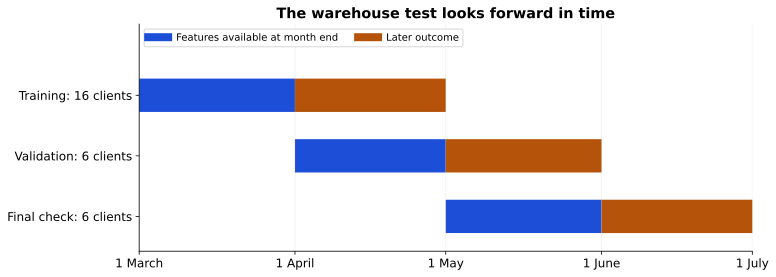

Figure 5. Feature and outcome months are separate. Final-test clients are excluded from training and validation; refitting uses only outcomes through May.

## Warehouse results: selection and final check

I chose **logistic regression** as the strongest learned candidate using validation Precision@50, with average precision and ROC AUC breaking ties. Across rules and learned models, validation preferred **momentum rule**. This choice was recorded before June outcomes were read.

**April-to-May validation.** The declining rate is 56.7% across 1,373 pages.

| Method | P@20 | P@50 | P@100 | ROC AUC | Average precision |
| --- | --- | --- | --- | --- | --- |
| momentum rule | 0.950 | 0.880 | 0.920 | 0.704 | 0.756 |
| volume rule | 0.350 | 0.340 | 0.430 | 0.471 | 0.530 |
| logistic regression | 0.850 | 0.840 | 0.850 | 0.769 | 0.786 |
| decision tree | 0.456 | 0.456 | 0.590 | 0.685 | 0.673 |
| random forest | 0.850 | 0.840 | 0.840 | 0.743 | 0.768 |

**May-to-June final check.** The declining rate is **31.1% across 5,696 pages**. The selected model has **80.0% Precision@50**, compared with **96.0% for the momentum rule** and **26.0% for the volume rule**.

| Method | P@20 | P@50 | P@100 | ROC AUC | Average precision |
| --- | --- | --- | --- | --- | --- |
| momentum rule | 1.000 | 0.960 | 0.940 | 0.700 | 0.556 |
| volume rule | 0.250 | 0.260 | 0.280 | 0.462 | 0.290 |
| logistic regression | 0.850 | 0.800 | 0.800 | 0.680 | 0.505 |

The model-minus-momentum difference is -16.0 percentage points at 50 review slots. Random ranking would average 15.5 declining pages per 50 picks. These results measure later decline, not the effect of an editorial change.

Ties are handled explicitly in this study: Precision@K is the expected result when ties at the cutoff are ordered randomly. For the selected model at K=50, the possible range from tied ordering is 80.0% to 80.0%. The receipt records these ranges for every method. This avoids giving a threshold rule or tree credit for an arbitrary file order.

As a simple robustness check, I remove one held-out client at a time without refitting. The model-minus-momentum Precision@50 difference ranges from -16.0 to +0.0 percentage points across 6 such checks. This is descriptive sensitivity, not a confidence interval or a significance test.

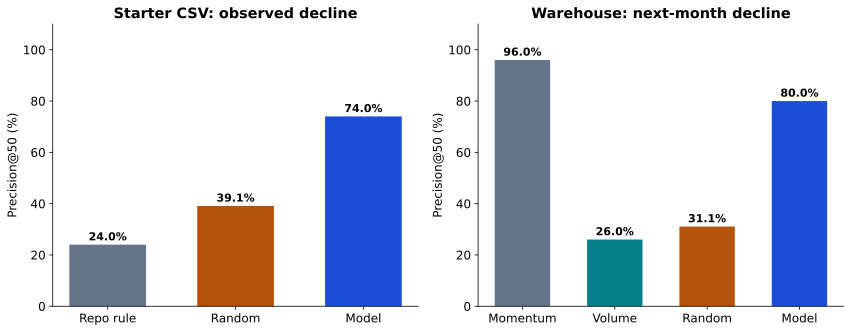

Figure 6. Each model is compared with baselines on its own evaluation set. The two panels use different populations, labels, features, and validation designs; their percentages are not a direct contest between datasets.

## Warehouse interpretation and review guidance

At score 0.5, the selected model makes 539 false-positive calls and misses 1,155 declining pages. Its accuracy is 70.3%; assigning every page to the majority class would give 68.9%. The other two counts are 615 true positives and 3,387 true negatives. The 0.5 cutoff is separate from a top-50 review budget.

The leading model inputs are `half_month_change`, `daily_impression_cv`, `log_impressions`. Their recorded interpretation is absolute standardized coefficients, not causal effects. These are descriptions of the fit, not proof that changing a feature will recover traffic.

For this warehouse task, I would start with the **momentum rule**. It led in validation and found 48 declining pages in the final top 50, compared with 40 for logistic regression. The rule is easier to explain and did better on this test; the learned model has not earned the extra work here. Check tracking and seasonality, compare related pages, and inspect the page before deciding whether a change is useful. The model's score is uncalibrated, and the review reasons are separate checks rather than causal explanations.

Below are the first five candidates in the **validation-preferred rule's** final-window demonstration. The [policy review receipt](outputs/warehouse_policy_review.json) contains all 20 with broad volume bands, suggested reviews, and reasons they could be wrong. The rule score is a ranking value, not a probability. These are generated review suggestions, not claims that I manually inspected the real pages.

| rank | rule_score | volume_band | action | reason | what_could_be_wrong |
| --- | --- | --- | --- | --- | --- |
| 1 | 10.153 | 10,000+ | Review recent loss, snippet, and intent | past_decline_and_low_ctr | Seasonality, tracking changes, or related-page gains |
| 2 | 9.938 | 10,000+ | Review recent loss, snippet, and intent | past_decline_and_low_ctr | Seasonality, tracking changes, or related-page gains |
| 3 | 9.833 | 10,000+ | Review recent loss, snippet, and intent | past_decline_and_low_ctr | Seasonality, tracking changes, or related-page gains |
| 4 | 9.493 | 10,000+ | Review recent loss, snippet, and intent | past_decline_and_low_ctr | Seasonality, tracking changes, or related-page gains |
| 5 | 9.191 | 10,000+ | Review recent loss, snippet, and intent | past_decline_and_low_ctr | Seasonality, tracking changes, or related-page gains |

## What the two datasets support

The CSV study reproduces the supplied benchmark: a model can match the current decline label more often than the four-part reference rule at the top of that list. Its overlapping windows and reused development holdout limit the claim.

The warehouse study tests a separate, forward-looking question. It fits preprocessing on earlier training rows, holds out whole clients, and evaluates a later outcome after recording model selection. On its final set, the model reaches 80.0% Precision@50, the momentum rule 96.0%, and the volume rule 26.0%, against a 31.1% base rate. The model wins the CSV comparison, but the simple momentum rule wins the warehouse forecast. That is the main practical finding. A different result from the CSV is not a contradiction: the question and candidate population changed.

Neither study measures the benefit of a refresh. The warehouse result also depends on reliable creation dates, March client eligibility, and sufficient tracking in the outcome month. Missing later outcomes are excluded, so this is not an evaluation of every page that a real editor would see. More client splits and later time windows would help establish whether the result holds.

[Warehouse metrics](outputs/warehouse_metrics.json) | [Recorded model choice](outputs/warehouse_selection_v2.json) | [Original pre-June choice](outputs/warehouse_selection_before_grain_fix.json) | [Warehouse analysis code](scripts/warehouse_capstone.py) | [Data inventory](outputs/warehouse_inventory.json)

The first warehouse run requires a saved Hugging Face read login with access to the gated release. The code reads only the selected columns, aggregates them, and reuses fingerprint-checked local caches on later runs. Its pinned revision and implementation follow [DuckDB's documented Hugging Face support](https://duckdb.org/docs/current/core_extensions/httpfs/hugging_face). Source dimensions, cache fingerprints, filters, model settings, and aggregate checks are recorded alongside the results.

In [9]:
import duckdb
duckdb.install_extension('httpfs')
from warehouse_capstone import run_warehouse
from warehouse_narrative import add_warehouse_sections
from warehouse_policy import build_policy_review
warehouse = run_warehouse(ROOT)
assert all(warehouse['checks'].values())
checks['warehouse_time_group_and_tracking_checks'] = True
warehouse_policy = build_policy_review(ROOT, warehouse)
assert all(warehouse_policy['checks'].values())
checks['warehouse_policy_matches_validation_choice'] = True
add_warehouse_sections(warehouse,
    {'model': best['precision_at_50'], 'baseline': base['precision_at_50'], 'base_rate': base_rate},
    section, table, figure, warehouse_policy)
warehouse_model = warehouse['selected_model']
warehouse_result = warehouse['test_metrics'][warehouse_model]
warehouse_rule = warehouse['test_metrics']['momentum_rule']


## 8. Be clear about the limits
A useful result still has limits. I want a reader to know what was tested, what was only explored, and what still needs another experiment.

In [10]:
section('Limitations and next checks', """
**The CSV study is a starter-snapshot benchmark.** It supports a comparison on the supplied 30,000 pages, not a result on the full warehouse or on future traffic. The actual declining label is already available at the snapshot; the model's value here is as a ranking experiment, not as a way to discover otherwise unknown decline.

**The outcome is a proxy.** Decline does not establish a need for a rewrite or likely recovery. Seasonality, tracking changes, competition, and consolidation can look similar in these aggregates. Pages with no exposure or age below 90 days are outside the sample.

**The CSV development holdout has been used to compare models.** There is no untouched final test or measured interval across repeated client splits. Only six clients are held out, their sizes differ, and the positive rate differs from the full sample. Results should not be generalized to every client.

**The CSV preprocessing has known weaknesses.** The reproduced benchmark uses full-sample percentiles and category vocabulary, zero-filled numeric gaps, and same-window traffic inputs. These choices are disclosed rather than described as a complete leakage pass. The identifier and direct-target checks cover only those specific risks.

**The action guidance has not been tested in production.** Scores are uncalibrated and evidence labels are heuristic. The saved March warehouse outputs need a clean rerun after correcting window overlap and equalizing exposure periods. The new warehouse experiment corrects those timing problems for a new monthly forecast; it does not validate the old March scores. The warehouse has separate client groups and a later final window, but it still assumes stable creation dates, uses one final period, and excludes insufficiently observed outcomes. Publishing and causal traffic recovery have not been demonstrated.
""")

## Limitations and next checks

**The CSV study is a starter-snapshot benchmark.** It supports a comparison on the supplied 30,000 pages, not a result on the full warehouse or on future traffic. The actual declining label is already available at the snapshot; the model's value here is as a ranking experiment, not as a way to discover otherwise unknown decline.

**The outcome is a proxy.** Decline does not establish a need for a rewrite or likely recovery. Seasonality, tracking changes, competition, and consolidation can look similar in these aggregates. Pages with no exposure or age below 90 days are outside the sample.

**The CSV development holdout has been used to compare models.** There is no untouched final test or measured interval across repeated client splits. Only six clients are held out, their sizes differ, and the positive rate differs from the full sample. Results should not be generalized to every client.

**The CSV preprocessing has known weaknesses.** The reproduced benchmark uses full-sample percentiles and category vocabulary, zero-filled numeric gaps, and same-window traffic inputs. These choices are disclosed rather than described as a complete leakage pass. The identifier and direct-target checks cover only those specific risks.

**The action guidance has not been tested in production.** Scores are uncalibrated and evidence labels are heuristic. The saved March warehouse outputs need a clean rerun after correcting window overlap and equalizing exposure periods. The new warehouse experiment corrects those timing problems for a new monthly forecast; it does not validate the old March scores. The warehouse has separate client groups and a later final window, but it still assumes stable creation dates, uses one final period, and excludes insufficiently observed outcomes. Publishing and causal traffic recovery have not been demonstrated.

## 9. Save receipts and build the paper
The HTML and Markdown paper are generated from the same text and values shown above. The original supplied metrics remain in a separate receipt. This cell also records the code and data fingerprints needed to trace the fresh run.

In [11]:
repo_url='https://github.com/Ibrahim-1rfan/Flyrank-'
versions={'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,
          'scikit-learn':sklearn.__version__,'matplotlib':matplotlib.__version__}
section('8. Reproducibility', f"""
[Repository]({repo_url}) | [Capstone notebook](notebooks/capstone.ipynb) | [Fresh metrics](outputs/capstone_metrics.json) | [Original supplied metrics](outputs/capstone_metrics_original.json)

The experiment uses the bundled starter file and seed 42. The CSV portion needs no login. The first warehouse run needs a saved Hugging Face read login (`hf auth login`) and access to `FlyRank/internship-warehouse`; later runs reuse local caches. From a fresh clone, run:

```text
python -m pip install -r requirements.txt
python -m pip install -r work/requirements-capstone.txt
python work/scripts/run_capstone.py
```

Or open `work/notebooks/capstone.ipynb` in Jupyter and run all cells. The notebook builds the features and held-out frame, runs both experiments, computes every result, and writes this paper. Keep the full `work/` layout when sharing the HTML so its notebook and metrics links resolve. Charts and styles are embedded in the HTML itself, so the paper also opens offline as one file.

This run uses: {', '.join(k+' '+v for k,v in versions.items())}. Direct analysis and notebook dependencies are pinned in `work/requirements-capstone.txt`. The metrics include a SHA-256 fingerprint of the input, the notebook code, the imported reference helpers, and the paper builder. Top-K scores with ties can vary across stacks; the receipt records their possible boundary range.

The delivered artifact is a local HTML paper. The internship also asks for a deployed page and its direct address in `submission/paper_url.txt`; a generated file alone does not establish publication.
""")
section('9. Acknowledgments and data credit', """
[Built on the FlyRank ML Internship dataset](https://flyrank.ai).

I used the repository's data dictionary, starter scripts, and capstone template, alongside my earlier assignment notebooks. AI assistance helped review the code and simplify the writing; the reported results are computed by this notebook. The checks support the stated benchmark, while the remaining limits stay visible.
""")
abstract=f"""Which mature pages should a content team review first when it has only 20 to 50 slots? I studied both the 30,000-page starter CSV and a separate monthly forecast built from the Hugging Face warehouse. The CSV comparison uses held-out clients with an overlapping historical label, while the warehouse keeps feature months before outcome months and reserves separate clients for its final May-to-June check. The CSV model reaches {best['precision_at_50']:.0%} Precision@50 versus {base['precision_at_50']:.0%} for its reference rule, and the warehouse model reaches {warehouse_result['precision_at_50']:.1%} versus {warehouse_rule['precision_at_50']:.1%} for its momentum rule, with base rates of {base_rate:.1%} and {warehouse['test_positive_rate']:.1%}, respectively. The model wins the CSV comparison while the simple momentum rule wins the warehouse forecast, and neither experiment proves that a refresh will recover traffic."""
display(Markdown('## Abstract (written after the results)\n\n'+abstract))

notebook_path=ROOT/'work/notebooks/capstone.ipynb'
notebook=json.loads(notebook_path.read_text(encoding='utf-8'))
code_text='\n\n'.join(''.join(c['source']) for c in notebook['cells'] if c['cell_type']=='code')
source_paths=['scripts/ml_utils.py','scripts/03_train_model.py','work/scripts/capstone_report.py','work/scripts/warehouse_capstone.py','work/scripts/warehouse_narrative.py','work/scripts/warehouse_policy.py']
source_hashes={p:hashlib.sha256((ROOT/p).read_bytes()).hexdigest() for p in source_paths}
original=json.loads((OUT/'capstone_metrics_original.json').read_text(encoding='utf-8'))
receipt={'schema_version':2,'question':'Which mature pages should be reviewed first for refresh?',
         'dataset_rows':len(frame),'declining_rate':float(y.mean()),'split_strategy':split_strategy,
         'best_model':best_name,'best_model_precision_at_50':best['precision_at_50'],
         'baseline_precision_at_50':base['precision_at_50'],'seed':SEED,
         'run_utc':datetime.now(timezone.utc).isoformat(),
         'data':{'source':'bundled starter CSV','raw_columns':raw.shape[1],
                 'source_sha256':hashlib.sha256(RAW.read_bytes()).hexdigest(),
                 'calendar_window':'not recorded in starter CSV','row_exclusions':len(raw)-len(frame),
                 'missing_measurements':missing.to_dict(orient='records'),'high_impact_declining_pages':high_impact},
         'split':{'train_rows':len(train_idx),'test_rows':len(test_idx),
                  'train_clients':train_clients,'test_clients':test_clients,
                  'train_positive_rate':float(y_train.mean()),'test_positive_rate':base_rate,
                  'test_positive_rows':int(y_test.sum()),'majority_accuracy':max(base_rate,1-base_rate),
                  'role':'development holdout used to compare models','sealed_final_test':False},
         'features':{'numeric':MODEL_NUMERIC_FEATURES,'categorical':MODEL_CATEGORICAL_FEATURES,
                     'encoded_count':len(encoded_features),'encoded':encoded_features},
         'metrics':metrics,'top50_tie_bounds':ties,
         'hand_rule':{'eligible_all':hand_eligible_all,'eligible_test':hand_eligible_test,
                      'precision_at_50':None,'random_tie_expected_precision':base_rate,
                      'note':'All held-out scores are zero; a top-K result would depend on tie order.'},
         'selected_model_errors_at_0_5':{'true_negative':tn,'false_positive':fp,'false_negative':fn,'true_positive':tp},
         'errors_by_volume':error_frame.to_dict(orient='records'),'training_feature_importance':importance,
         'original_receipt_comparison':{'original_model_p50':original['best_model_precision_at_50'],
                                        'original_baseline_p50':original['baseline_precision_at_50'],
                                        'model_difference':best['precision_at_50']-original['best_model_precision_at_50'],
                                        'baseline_difference':base['precision_at_50']-original['baseline_precision_at_50']},
         'checks':checks,'versions':versions,'notebook_code_sha256':hashlib.sha256(code_text.encode()).hexdigest(),
         'source_sha256':source_hashes,
         'limitations':['snapshot feature-label overlap','development holdout reused for selection',
                        'full-sample reference transforms','zero-filled missing values','no causal experiment'],
         'warehouse_evaluation_rerun':True,'warehouse_metrics_file':'work/outputs/warehouse_metrics.json','warehouse_metrics_sha256':hashlib.sha256((OUT/'warehouse_metrics.json').read_bytes()).hexdigest(),'warehouse_policy_sha256':hashlib.sha256((OUT/'warehouse_policy_review.json').read_bytes()).hexdigest(),'published':False}
(OUT/'capstone_metrics.json').write_text(json.dumps(receipt,indent=2,allow_nan=False)+'\n',encoding='utf-8')
paper=save_paper(ROOT,abstract,sections,receipt)
print('Wrote work/capstone_report.html, work/capstone_report.md, six figures, and fresh metrics.')

## 8. Reproducibility

[Repository](https://github.com/Ibrahim-1rfan/Flyrank-) | [Capstone notebook](notebooks/capstone.ipynb) | [Fresh metrics](outputs/capstone_metrics.json) | [Original supplied metrics](outputs/capstone_metrics_original.json)

The experiment uses the bundled starter file and seed 42. The CSV portion needs no login. The first warehouse run needs a saved Hugging Face read login (`hf auth login`) and access to `FlyRank/internship-warehouse`; later runs reuse local caches. From a fresh clone, run:

```text
python -m pip install -r requirements.txt
python -m pip install -r work/requirements-capstone.txt
python work/scripts/run_capstone.py
```

Or open `work/notebooks/capstone.ipynb` in Jupyter and run all cells. The notebook builds the features and held-out frame, runs both experiments, computes every result, and writes this paper. Keep the full `work/` layout when sharing the HTML so its notebook and metrics links resolve. Charts and styles are embedded in the HTML itself, so the paper also opens offline as one file.

This run uses: python 3.10.11, numpy 2.2.6, pandas 2.3.3, scikit-learn 1.7.2, matplotlib 3.8.4. Direct analysis and notebook dependencies are pinned in `work/requirements-capstone.txt`. The metrics include a SHA-256 fingerprint of the input, the notebook code, the imported reference helpers, and the paper builder. Top-K scores with ties can vary across stacks; the receipt records their possible boundary range.

The delivered artifact is a local HTML paper. The internship also asks for a deployed page and its direct address in `submission/paper_url.txt`; a generated file alone does not establish publication.

## 9. Acknowledgments and data credit

[Built on the FlyRank ML Internship dataset](https://flyrank.ai).

I used the repository's data dictionary, starter scripts, and capstone template, alongside my earlier assignment notebooks. AI assistance helped review the code and simplify the writing; the reported results are computed by this notebook. The checks support the stated benchmark, while the remaining limits stay visible.

## Abstract (written after the results)

Which mature pages should a content team review first when it has only 20 to 50 slots? I studied both the 30,000-page starter CSV and a separate monthly forecast built from the Hugging Face warehouse. The CSV comparison uses held-out clients with an overlapping historical label, while the warehouse keeps feature months before outcome months and reserves separate clients for its final May-to-June check. The CSV model reaches 74% Precision@50 versus 24% for its reference rule, and the warehouse model reaches 80.0% versus 96.0% for its momentum rule, with base rates of 39.1% and 31.1%, respectively. The model wins the CSV comparison while the simple momentum rule wins the warehouse forecast, and neither experiment proves that a refresh will recover traffic.

Wrote work/capstone_report.html, work/capstone_report.md, six figures, and fresh metrics.


## ML-12: explain the project in five minutes
These short versions use the same fresh values as the paper. I would show the question, the baseline, the comparison chart, and one review example, then explain the limits.

In [12]:
demo=f"""
### Five-minute demo
1. **0:00-0:45 - The question.** An editor has time for 20 to 50 pages. Explain the cost of a weak pick.
2. **0:45-1:30 - The data.** Show the starter and warehouse timing diagrams. Explain the difference between matching current decline and forecasting next-month decline.
3. **1:30-2:30 - The comparison.** Show the CSV baseline, warehouse momentum rule, and three warehouse client groups.
4. **2:30-3:45 - The result and errors.** Show both datasets, their own baselines, and their own base rates. The warehouse model has {warehouse_result['precision_at_50']:.1%} Precision@50 versus {warehouse_rule['precision_at_50']:.1%} for the momentum rule.
5. **3:45-5:00 - The action and limits.** Walk through a row of the review list. Explain that a human checks the context, the score is not a recovery promise, and the completed warehouse test still covers only one final time window.

### Social-post cut
I worked on a simple content question: which pages should an editor review first? On a 30,000-page FlyRank starter sample, the strongest model found {selected_hits} declining pages among its first 50 picks, compared with {baseline_hits} for the repo rule. I used held-out clients and checked the errors, but this is still a historical benchmark with overlapping time windows. I also built a warehouse forecast with separate months and clients: its final Precision@50 is {warehouse_result['precision_at_50']:.1%} versus {warehouse_rule['precision_at_50']:.1%} for its momentum rule. The momentum rule won that forecast test. Each result has a different label and population; neither promises that a rewrite brings traffic back.

### Employer-facing summary
I built a reproducible content-review ranking study using 30,000 anonymized pages. It compares a transparent baseline with three models on held-out clients and reports {best['precision_at_50']:.0%} versus {base['precision_at_50']:.0%} Precision@50. A second experiment uses the Hugging Face warehouse to forecast next-month decline with separate training, validation, and final-test clients. The simple momentum rule outperformed the learned model on the final warehouse check (96% versus 80% Precision@50), so the recommendation follows that evidence. Both experiments are documented with their own baselines and limitations.
"""
display(Markdown(demo))
(ROOT/'work/capstone_demo.md').write_text(demo.strip()+'\n',encoding='utf-8')


### Five-minute demo
1. **0:00-0:45 - The question.** An editor has time for 20 to 50 pages. Explain the cost of a weak pick.
2. **0:45-1:30 - The data.** Show the starter and warehouse timing diagrams. Explain the difference between matching current decline and forecasting next-month decline.
3. **1:30-2:30 - The comparison.** Show the CSV baseline, warehouse momentum rule, and three warehouse client groups.
4. **2:30-3:45 - The result and errors.** Show both datasets, their own baselines, and their own base rates. The warehouse model has 80.0% Precision@50 versus 96.0% for the momentum rule.
5. **3:45-5:00 - The action and limits.** Walk through a row of the review list. Explain that a human checks the context, the score is not a recovery promise, and the completed warehouse test still covers only one final time window.

### Social-post cut
I worked on a simple content question: which pages should an editor review first? On a 30,000-page FlyRank starter sample, the strongest model found 37 declining pages among its first 50 picks, compared with 12 for the repo rule. I used held-out clients and checked the errors, but this is still a historical benchmark with overlapping time windows. I also built a warehouse forecast with separate months and clients: its final Precision@50 is 80.0% versus 96.0% for its momentum rule. The momentum rule won that forecast test. Each result has a different label and population; neither promises that a rewrite brings traffic back.

### Employer-facing summary
I built a reproducible content-review ranking study using 30,000 anonymized pages. It compares a transparent baseline with three models on held-out clients and reports 74% versus 24% Precision@50. A second experiment uses the Hugging Face warehouse to forecast next-month decline with separate training, validation, and final-test clients. The simple momentum rule outperformed the learned model on the final warehouse check (96% versus 80% Precision@50), so the recommendation follows that evidence. Both experiments are documented with their own baselines and limitations.


2090

## Final checks
These checks cover the notebook and the generated files. These checks include the warehouse forecast experiment. Publication remains a separate step; it is not silently ticked off here.

In [13]:
from html.parser import HTMLParser
class PaperParser(HTMLParser):
    def __init__(self):
        super().__init__();self.refs=[];self.ids=set();self.headings=0
    def handle_starttag(self,tag,attrs):
        attrs=dict(attrs)
        if 'id' in attrs:self.ids.add(attrs['id'])
        if tag=='h2':self.headings+=1
        for key in ['href','src']:
            if attrs.get(key):self.refs.append(attrs[key])
html=(ROOT/'work/capstone_report.html').read_text(encoding='utf-8')
parser=PaperParser();parser.feed(html)
for ref in parser.refs:
    if ref.startswith('#'):assert ref[1:] in parser.ids,ref
    elif not ref.startswith(('https://','data:')):
        assert (ROOT/'work'/ref).exists(),ref
assert parser.headings==9
assert html.count('<svg')==6
assert 'https://flyrank.ai' in html
assert not any(str(value) in html for col in ['content_id','client_id'] for value in raw[col].unique())
assert all(warehouse['checks'].values())
assert all(warehouse_policy['checks'].values())
assert all(checks.values())
saved=json.loads((OUT/'capstone_metrics.json').read_text(encoding='utf-8'))
assert saved['best_model_precision_at_50']==best['precision_at_50']
assert saved['warehouse_metrics_sha256']==hashlib.sha256((OUT/'warehouse_metrics.json').read_bytes()).hexdigest()
assert saved['selected_model_errors_at_0_5']['false_positive']==fp
assert saved['split']['test_rows']==sum(cm.ravel())
checks['paper_links_figures_metrics_and_identifiers_checked']=True
saved['checks']=checks
(OUT/'capstone_metrics.json').write_text(json.dumps(saved,indent=2,allow_nan=False)+'\n',encoding='utf-8')
print(f'PASS: {len(checks)} checks. Notebook results, paper, figures, and receipt agree.')
print('Publication status: local HTML file created; no deployment claimed.')

PASS: 9 checks. Notebook results, paper, figures, and receipt agree.
Publication status: local HTML file created; no deployment claimed.
